Total Revenue: 9253.0
Average Package Weight: 157.91

Delivery Status Counts:
delivery_status
Delivered    52
Late         31
Failed       21
Name: count, dtype: int64

Bottom Customers By Total Package Weight:
customer_name
Quick Letter Office Supplies            991.0
Fresh Bread Mart Retail                1445.0
Care Plan Plus Clinics                 1650.0
Medi Yedi Supply UK                    1740.0
Urban Street Fashion Style Clothing    1757.0
Name: package_weight_kg, dtype: float64

Shipments By Customer:
depot_name
London South Depot          31
Birmingham Central Depot    31
Manchester North Depot      19
Bristol West Depot          13
Leeds Distribution Hub      10
Name: count, dtype: int64


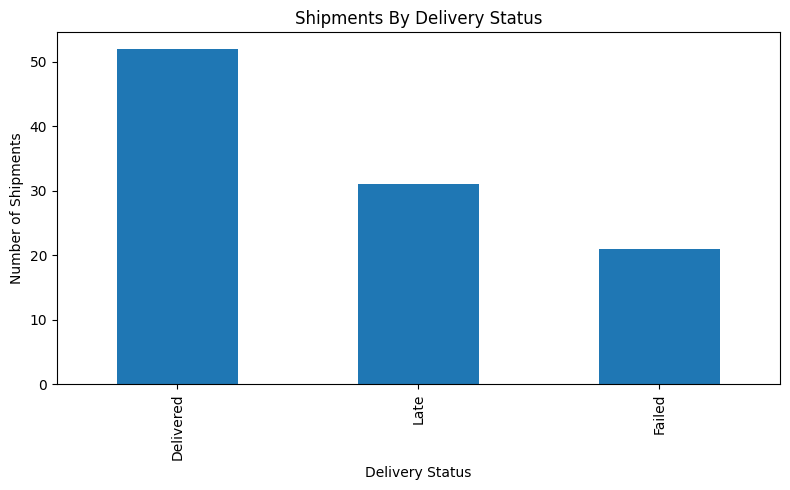

<Figure size 800x500 with 0 Axes>

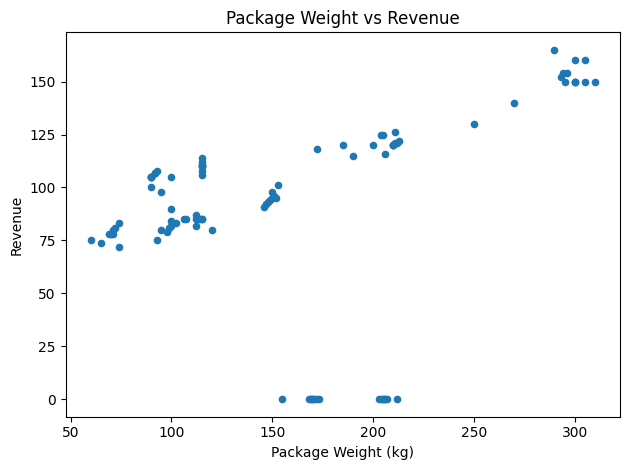

{3: 12, 2: 4, 5: 10, 1: 5}
depot_id
1     5
2     4
3    12
5    10
dtype: int64


In [79]:
import pandas as pd;
import matplotlib.pyplot as plt;

# Loading In CSV Data
shipments = pd.read_csv("shipments.csv");
customers = pd.read_csv("customers.csv");
depots = pd.read_csv("depots.csv");

# Merging CSV Files
shipments_customers = shipments.merge(
    customers,
    on="customer_id",
    how="left"
);

shipments_depots = shipments.merge(
    depots,
    on="depot_id",
    how="left"
);

# KPI Stats
## Question 1: What is the total revenue generated?
print("Total Revenue:", shipments["revenue"].sum());

## Question 2: What is the average package weight across all shipments?
print("Average Package Weight:", round(shipments["package_weight_kg"].mean(), 2));

## Question 3: Which delivery status occurs most frequently?
print("\nDelivery Status Counts:");
print(shipments["delivery_status"]
      .value_counts()
);

## Question 4: Which customers generate the least package weight?
print("\nBottom Customers By Total Package Weight:")
print(
    shipments_customers
    .groupby("customer_name")["package_weight_kg"]
    .sum()
    .sort_values(ascending=1)
    .head(5)
);

## Question 5: Which depots process the most shipments?
print("\nShipments By Customer:")
print(shipments_depots["depot_name"]
      .value_counts()
);

# Bar Chart: Shipments By Delivery Status
plt.figure(figsize=(8, 5));
shipments["delivery_status"].value_counts().plot.bar();
plt.title("Shipments By Delivery Status");
plt.xlabel("Delivery Status");
plt.ylabel("Number of Shipments");
plt.tight_layout();
plt.show();

# Scatter Chart: Package Weight vs Revenue
plt.figure(figsize=(8, 5));
shipments.plot.scatter(
    x="package_weight_kg",
    y="revenue"
);
plt.title("Package Weight vs Revenue");
plt.xlabel("Package Weight (kg)");
plt.ylabel("Revenue");
plt.tight_layout();
plt.show();

depot_counts = {}

for index, row in shipments.iterrows():

    depot_id = row["depot_id"]

    if row["delivery_status"] == "Late":

        if depot_id in depot_counts:
            depot_counts[depot_id] = depot_counts[depot_id] + 1
        else:
            depot_counts[depot_id] = 1

print(depot_counts);

late_shipments = shipments[
    shipments["delivery_status"] == "Late"
]

total_late_shipments_by_depot = late_shipments.groupby("depot_id").size();

print(total_late_shipments_by_depot);


